# Experiment 02 - Task 03

## Performance Assessment using Confusion Matrix, Precision, Recall, F1-Score, ROC Analysis, and Cross-Validation

## Student Details

**Name:** Manjunadh  
**Course:** B.Tech AIML  
**Experiment:** 02  
**Task:** 03

## Objective

To evaluate the performance of a classification model using confusion matrix, accuracy, precision, recall, F1-score, ROC analysis, and cross-validation techniques.

Task 3: Evaluate feature importance and implement feature selection techniques for enhanced predictive performance
Dataset Utilized: Pima Indians Diabetes Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [4]:
from google.colab import files

uploaded = files.upload()

Saving sonar.csv to sonar.csv


In [6]:
sonar = pd.read_csv("sonar.csv", header=None)

print("Dataset Shape:", sonar.shape)

sonar.head()

Dataset Shape: (208, 61)


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [7]:
X = sonar.iloc[:, :-1]
y = sonar.iloc[:, -1]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nClass Distribution:")
print(y.value_counts())

Features: (208, 60)
Target: (208,)

Class Distribution:
60
M    111
R     97
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 166
Testing samples: 42


In [9]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8571428571428571


Confusion Matrix:
[[21  1]
 [ 5 15]]


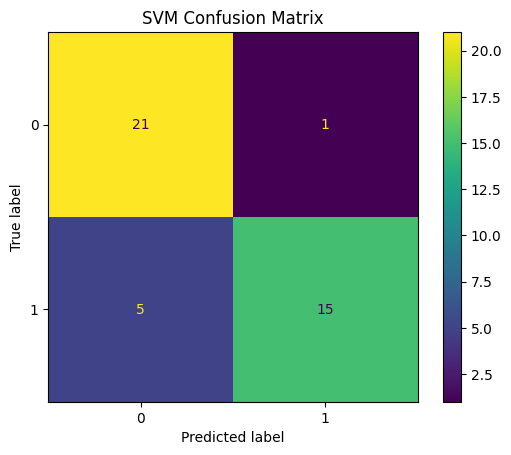

In [11]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [12]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label="M"
)

print("Precision:", precision)

Precision: 0.8076923076923077


In [13]:
recall = recall_score(
    y_test,
    y_pred,
    pos_label="M"
)

print("Recall:", recall)

Recall: 0.9545454545454546


In [14]:
f1 = f1_score(
    y_test,
    y_pred,
    pos_label="M"
)

print("F1-Score:", f1)

F1-Score: 0.875


In [15]:
y_test_binary = (y_test == "M").astype(int)

fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    y_prob
)

auc_score = roc_auc_score(
    y_test_binary,
    y_prob
)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.07500000000000001


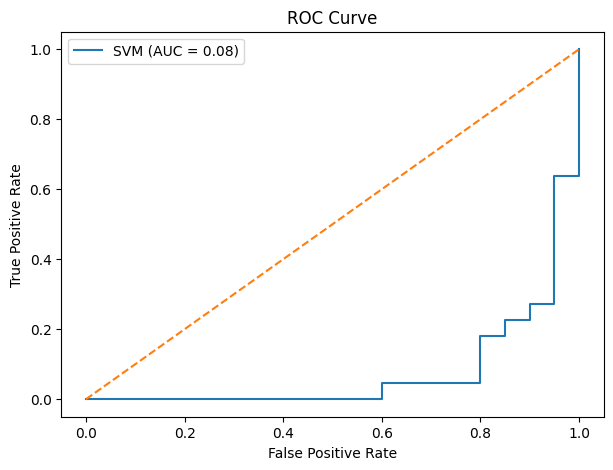

In [16]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"SVM (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [17]:
cv_scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation Scores:
[0.54761905 0.78571429 0.61904762 0.70731707 0.53658537]

Mean CV Accuracy: 0.6392566782810685
Standard Deviation: 0.09531978593305387


In [18]:
performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Mean CV Accuracy"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score,
        cv_scores.mean()
    ]
})

performance

,Metric,Score
0,Accuracy,0.857143
1,Precision,0.807692
2,Recall,0.954545
3,F1-Score,0.875000
4,ROC-AUC,0.075000
5,Mean CV Accuracy,0.639257


In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [24]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

pima_df = pd.read_csv(url, names=columns)

pima_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
print(pima_df.shape)

(768, 9)


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = pima_df[features]
y = pima_df["Outcome"]

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X_standardized, y)

anova_scores = pd.DataFrame({
    "Feature": features,
    "F-Score": selector.scores_
}).sort_values("F-Score", ascending=False)

print("ANOVA F-Test Scores:")
print(anova_scores)

print("\nTop 4 Features:")
print(anova_scores.head(4))

ANOVA F-Test Scores:
                    Feature     F-Score
1                   Glucose  213.161752
5                       BMI   71.772072
7                       Age   46.140611
0               Pregnancies   39.670227
6  DiabetesPedigreeFunction   23.871300
4                   Insulin   13.281108
3             SkinThickness    4.304381
2             BloodPressure    3.256950

Top 4 Features:
       Feature     F-Score
1      Glucose  213.161752
5          BMI   71.772072
7          Age   46.140611
0  Pregnancies   39.670227


In [27]:
pima_df.to_csv("diabetes.csv", index=False)

In [29]:
from google.colab import files

files.download("diabetes.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
pima_df = pd.read_csv("diabetes.csv")

pima_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [31]:
from sklearn.feature_selection import SelectKBest, f_classif

# Rank and select the top 4 features using SelectKBest (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X_standardized, pima_df['Outcome'])

# Build a summary DataFrame of feature scores
anova_scores = pd.DataFrame({'Feature': features, 'F-Score': selector.scores_}).sort_values(by='F-Score', ascending=False)
print("ANOVA F-Test Scores:\n", anova_scores)


ANOVA F-Test Scores:
                     Feature     F-Score
1                   Glucose  213.161752
5                       BMI   71.772072
7                       Age   46.140611
0               Pregnancies   39.670227
6  DiabetesPedigreeFunction   23.871300
4                   Insulin   13.281108
3             SkinThickness    4.304381
2             BloodPressure    3.256950


In [32]:
from sklearn.feature_selection import SelectKBest, f_classif

# Rank and select the top 4 features using SelectKBest (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X_standardized, pima_df['Outcome'])

# Build a summary DataFrame of feature scores
anova_scores = pd.DataFrame({'Feature': features, 'F-Score': selector.scores_}).sort_values(by='F-Score', ascending=False)
print("ANOVA F-Test Scores:\n", anova_scores)


ANOVA F-Test Scores:
                     Feature     F-Score
1                   Glucose  213.161752
5                       BMI   71.772072
7                       Age   46.140611
0               Pregnancies   39.670227
6  DiabetesPedigreeFunction   23.871300
4                   Insulin   13.281108
3             SkinThickness    4.304381
2             BloodPressure    3.256950


In [33]:
from sklearn.linear_model import LogisticRegression

# Run Logistic Regression with Lasso (L1) regularization
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
lasso.fit(X_standardized, pima_df['Outcome'])

# Display feature coefficients (zero-coefficients indicate dropped features)
lasso_coefs = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)
print("Lasso Regularization Coefficients:\n", lasso_coefs)

Lasso Regularization Coefficients:
                     Feature  Coefficient
1                   Glucose     1.082972
5                       BMI     0.667662
0               Pregnancies     0.395179
6  DiabetesPedigreeFunction     0.289774
2             BloodPressure    -0.223025
7                       Age     0.161596
4                   Insulin    -0.107260
3             SkinThickness     0.000000


Random Forest Feature Importances:
                     Feature  Importance
1                   Glucose    0.267142
5                       BMI    0.168769
7                       Age    0.131567
6  DiabetesPedigreeFunction    0.122695
2             BloodPressure    0.088660
0               Pregnancies    0.085017
4                   Insulin    0.071547
3             SkinThickness    0.064604


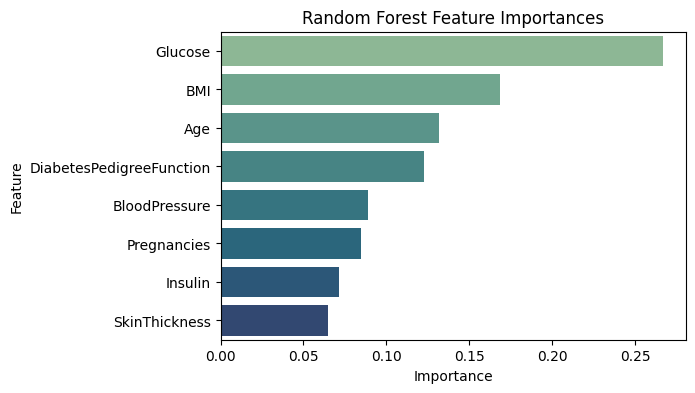

In [34]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Train Random Forest to compute Gini feature importances
rf = RandomForestClassifier(random_state=42)
rf.fit(X, pima_df['Outcome']) # Random Forest is scale invariant; raw values are suitable

# Plot feature importances
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
print("Random Forest Feature Importances:\n", importances)

plt.figure(figsize=(6, 4))
sns.barplot(data=importances, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Feature Importances")
plt.show()


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split dataset into training and test sets
X_train, X_test, y_train_p, y_test_p = train_test_split(X, pima_df['Outcome'], test_size=0.3, random_state=42)

# Model 1: Train on all 8 features
rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(X_train, y_train_p)
preds_full = rf_full.predict(X_test)

# Model 2: Train on only the top 4 features identified by Random Forest
top_4_cols = importances.head(4)['Feature'].tolist()
X_train_sub = X_train[top_4_cols]
X_test_sub = X_test[top_4_cols]

rf_sub = RandomForestClassifier(random_state=42)
rf_sub.fit(X_train_sub, y_train_p)
preds_sub = rf_sub.predict(X_test_sub)

print("--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---")
print(classification_report(y_test_p, preds_full))

print("\n--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---")
print(classification_report(y_test_p, preds_sub))

--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       151
           1       0.64      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.76      0.75      0.75       231


--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---
              precision    recall  f1-score   support

           0       0.81      0.76      0.78       151
           1       0.60      0.66      0.63        80

    accuracy                           0.73       231
   macro avg       0.70      0.71      0.71       231
weighted avg       0.74      0.73      0.73       231

